# Iris Flower Classification

## Project Overview

The objective of this project is to analyze the Iris flower dataset and build a basic machine learning model that can classify Iris flowers into different species.

The dataset contains measurements of:
- Sepal length
- Sepal width
- Petal length
- Petal width

There are three different Iris species:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

In this project, we will explore the dataset, perform basic data analysis, visualize patterns, and build a machine learning model for classification.

## 1. Importing Libraries

First, we import the required libraries for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 2. Loading the Dataset

Let's load the Iris dataset and take a look at the first few rows.

In [2]:
df = pd.read_csv("IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Understanding the Dataset

Before analyzing the data, let's understand its size, columns, data types, and basic statistics.

In [3]:
df.shape

(150, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. Checking Missing and Duplicate Values

Before analyzing the dataset, we check for missing and duplicate values.

In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


In [8]:
df = df.drop_duplicates()

df.shape

(147, 5)

## 5. Exploring the Iris Species

Let's check how many flowers of each species are present in the dataset.

In [9]:
df["species"].value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

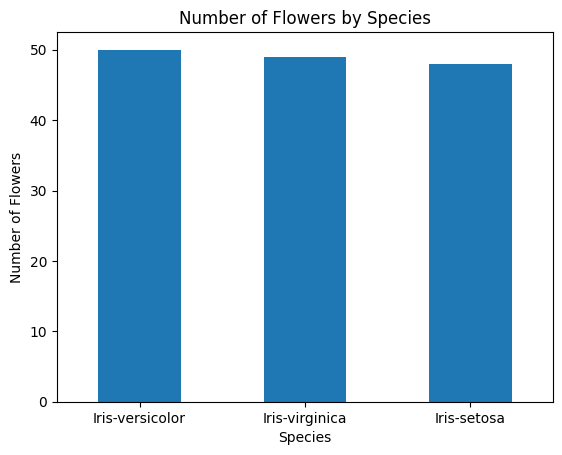

In [10]:
df["species"].value_counts().plot(kind="bar")

plt.title("Number of Flowers by Species")
plt.xlabel("Species")
plt.ylabel("Number of Flowers")
plt.xticks(rotation=0)
plt.show()

The dataset contains flowers belonging to three different Iris species: Setosa, Versicolor, and Virginica.

## 6. Exploratory Data Analysis

Now let's visualize some of the flower measurements and observe how they differ among the three species.

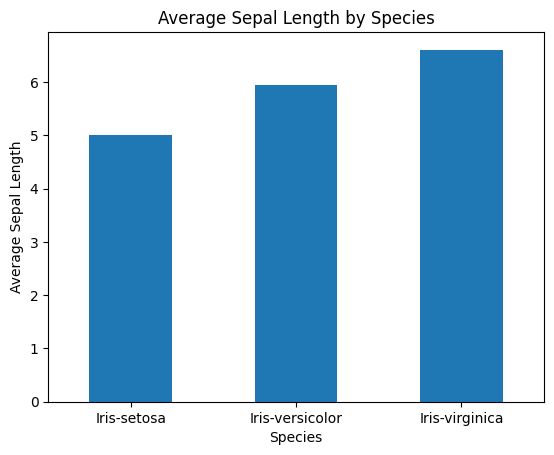

In [11]:
df.groupby("species")["sepal_length"].mean().plot(kind="bar")

plt.title("Average Sepal Length by Species")
plt.xlabel("Species")
plt.ylabel("Average Sepal Length")
plt.xticks(rotation=0)
plt.show()

The graph shows that the average sepal length differs among the three Iris species.

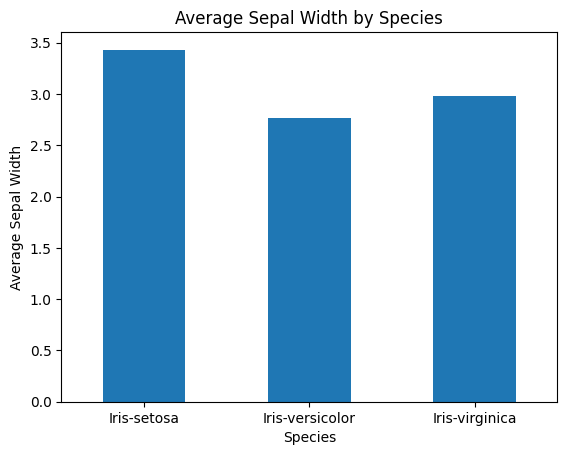

In [12]:
df.groupby("species")["sepal_width"].mean().plot(kind="bar")

plt.title("Average Sepal Width by Species")
plt.xlabel("Species")
plt.ylabel("Average Sepal Width")
plt.xticks(rotation=0)
plt.show()

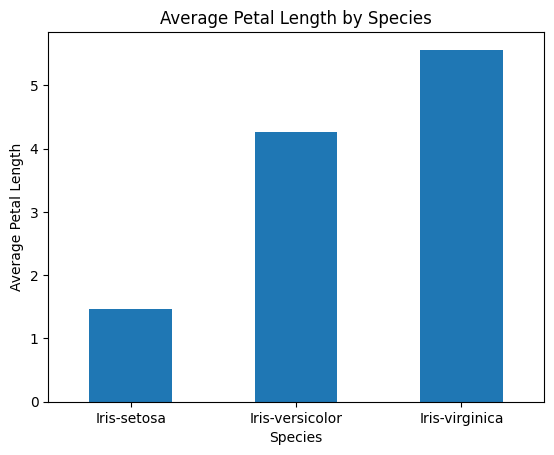

In [13]:
df.groupby("species")["petal_length"].mean().plot(kind="bar")

plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Average Petal Length")
plt.xticks(rotation=0)
plt.show()

The graph shows clear differences in average petal length among the three species.

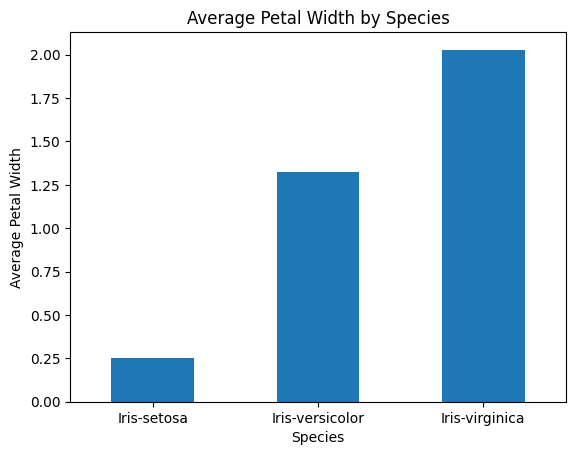

In [14]:
df.groupby("species")["petal_width"].mean().plot(kind="bar")

plt.title("Average Petal Width by Species")
plt.xlabel("Species")
plt.ylabel("Average Petal Width")
plt.xticks(rotation=0)
plt.show()

## 7. Preparing the Data for Machine Learning

For this classification task, the flower measurements will be used as input features, while the species column will be the target that we want to predict.

In [15]:
X = df.drop("species", axis=1)

y = df["species"]

## 8. Splitting the Dataset

The dataset is divided into training and testing data.

The model will learn from the training data, while the testing data will be used to check its performance on unseen data.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 9. Training the Model

We will use a Random Forest Classifier to learn patterns from the flower measurements and classify the flowers into their respective species.

In [17]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 10. Making Predictions

Now that the model has been trained, we use it to predict the species of flowers in the testing data.

In [18]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa'], dtype=object)

## 11. Checking Model Accuracy

Finally, we compare the predicted species with the actual species to calculate the accuracy of the model.

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 93.33 %


## 12. Conclusion

In this project, we explored the Iris flower dataset and analyzed the measurements of different Iris species.

We checked and cleaned the dataset, performed exploratory data analysis using visualizations, and used flower measurements such as sepal length, sepal width, petal length, and petal width to train a Random Forest classification model.

The trained model was then used to classify Iris flowers into Setosa, Versicolor, and Virginica species.

This project demonstrates a basic classification workflow using Python and machine learning.